In [ ]:
# install deps
!pip install scikeras scikit-learn==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 85.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
# Settings
import keras
import matplotlib.pyplot as plt
import seaborn as sns

# Set the seed for keras
keras.utils.set_random_seed(42)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# Set all text weights and sizes to 14 Bold globally
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

# Ensure individual components inherit the bold styling and size
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'

# Apply bold to axis tick numbers
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Task 1: Dataset Exploration

In [ ]:
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# Load the Fashion MNIST Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


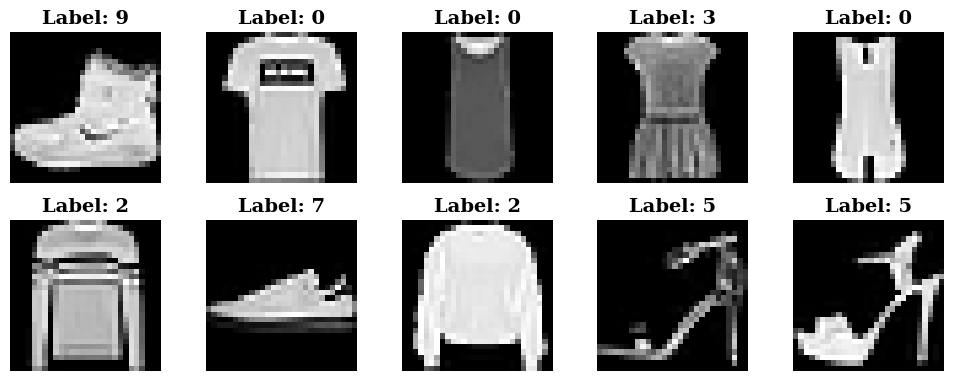

In [ ]:
# Plot the first 10 samples
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.savefig('mnist_sample_images.eps', format='eps', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

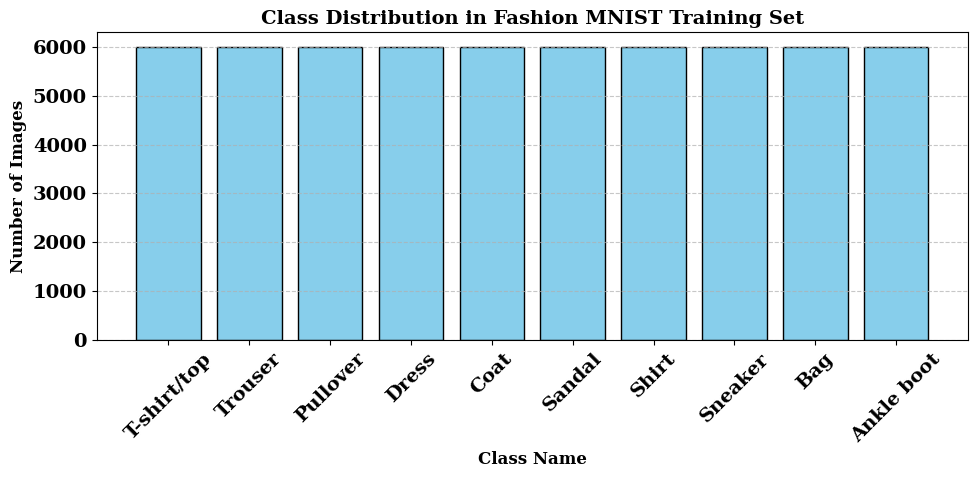

In [ ]:
# Plot the class distribution
import numpy as np

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Count the frequency of each class label
classes, counts = np.unique(y_train, return_counts=True)

# 3. Plot the distribution
plt.figure(figsize=(10, 5))
plt.bar(class_names, counts, color='skyblue', edgecolor='black')

# Add labels and formatting
plt.title('Class Distribution in Fashion MNIST Training Set', fontsize=14)
plt.xlabel('Class Name', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45) # Rotate names so they don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('mnist_class_distribution.eps', format='eps', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Task 2: Data Preprocessing

In [ ]:
# Flatten the images
print("Training data shape: ", X_train.shape)
print("Test data shape: ", X_test.shape)

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

print("Flattened data shape: ", X_train.shape)
print("Flattened Test data shape: ", X_test.shape)

Training data shape:  (60000, 28, 28)
Test data shape:  (10000, 28, 28)
Flattened data shape:  (60000, 784)
Flattened Test data shape:  (10000, 784)


In [ ]:
# Normalize the data
X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min())
X_test = (X_test - X_train.min()) / (X_train.max() - X_train.min())

In [ ]:
# One hot encode the labels
from keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Task 3: Model Construction

In [ ]:
import tensorflow as tf
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Model Training

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8177 - loss: 0.5109 - val_accuracy: 0.8559 - val_loss: 0.4044
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8641 - loss: 0.3735 - val_accuracy: 0.8683 - val_loss: 0.3629
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8772 - loss: 0.3354 - val_accuracy: 0.8692 - val_loss: 0.3619
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8844 - loss: 0.3111 - val_accuracy: 0.8739 - val_loss: 0.3492
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8913 - loss: 0.2911 - val_accuracy: 0.8760 - val_loss: 0.3475
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8964 - loss: 0.2752 - val_accuracy: 0.8801 - val_loss: 0.3510
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9015 - loss: 0.2617 - val_accuracy: 0.8817 - val_loss: 0.3451
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9064 - loss: 0.2488 -

# Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_probs_base = model.predict(X_test)
y_pred_base = np.argmax(y_pred_probs_base, axis=1)

# Ensure y_true is in 1D integer label format
y_true = np.argmax(y_test, axis=1)

acc_base = accuracy_score(y_true, y_pred_base)
prec_base = precision_score(y_true, y_pred_base, average='macro')
rec_base = recall_score(y_true, y_pred_base, average='macro')
f1_base = f1_score(y_true, y_pred_base, average='macro')

print(f"Baseline Accuracy:  {acc_base:.4f}")
print(f"Baseline Precision: {prec_base:.4f}")
print(f"Baseline Recall:    {rec_base:.4f}")
print(f"Baseline F1-Score:  {f1_base:.4f}\n")

print("Classification Report (Baseline Model):")
print(classification_report(y_true, y_pred_base, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline Accuracy:  0.8497
Baseline Precision: 0.8578
Baseline Recall:    0.8497
Baseline F1-Score:  0.8479

Classification Report (Baseline Model):
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.77      0.79      1000
     Trouser       0.96      0.98      0.97      1000
    Pullover       0.83      0.62      0.71      1000
       Dress       0.93      0.81      0.87      1000
        Coat       0.63      0.94      0.75      1000
      Sandal       0.98      0.93      0.95      1000
       Shirt       0.68      0.56      0.61      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.90      0.98      0.94      1000
  Ankle boot       0.94      0.96      0.95      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

def create_mlp_model(hidden_layers=2, hidden_neurons=128, optimizer='adam',
                     learning_rate=0.001, activation='relu', dropout_rate=0.0):

    # Map optimizer strings to TensorFlow objects to allow learning rate tuning
    opt_dict = {
        'adam': tf.keras.optimizers.Adam(learning_rate=learning_rate),
        'sgd': tf.keras.optimizers.SGD(learning_rate=learning_rate),
        'rmsprop': tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    }

    # Handle optimizer selection (case-insensitive string match)
    opt_key = optimizer.lower() if isinstance(optimizer, str) else 'adam'
    chosen_optimizer = opt_dict.get(opt_key, tf.keras.optimizers.Adam(learning_rate=learning_rate))

    # Construct network dynamically based on hyperparameter choices
    model = keras.Sequential()

    # Input Layer
    model.add(layers.Input(shape=(X_train.shape[1],)))

    # Add hidden layers and optional dropout
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(layers.Dropout(dropout_rate))

    # Output Layer
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer=chosen_optimizer,
        loss='categorical_crossentropy',  # Accepts 2D One-Hot vectors!
        metrics=['accuracy']
    )
    return model

# 2. Wrap model in SciKeras Classifier
keras_clf = KerasClassifier(model=create_mlp_model, verbose=0)

# 3. Define the Hyperparameter Search Space (matching Section 7 requirements)
param_distributions = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'model__optimizer': ['sgd', 'adam', 'rmsprop'],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30]
}

# 4. Perform Randomized Search CV with 5-Fold Cross Validation
print("Running RandomizedSearchCV (sampling combinations across 5-fold CV)...")
search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_distributions,
    n_iter=10,             # Number of random parameter combinations to try
    cv=5,                  # 5-fold cross validation
    scoring='accuracy',
    random_state=42,
    n_jobs=1,
    verbose=2
)

search.fit(X_train, y_train)

print("\nBest Hyperparameters Found:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

print(f"Best 5-Fold CV Accuracy: {search.best_score_:.4f}")

# 5. Evaluate the Best Optimized Model on the Test Dataset
best_model = search.best_estimator_
y_pred_opt = best_model.predict(X_test)

y_true_test = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test
y_pred_labels = np.argmax(y_pred_opt, axis=1) if y_pred_opt.ndim > 1 else y_pred_opt

acc_opt = accuracy_score(y_true_test, y_pred_labels)
prec_opt = precision_score(y_true_test, y_pred_labels, average='macro')
rec_opt = recall_score(y_true_test, y_pred_labels, average='macro')
f1_opt = f1_score(y_true_test, y_pred_labels, average='macro')

print(f"\nOptimized Test Accuracy: {acc_opt:.4f}")

Running RandomizedSearchCV (sampling combinations across 5-fold CV)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time=  41.3s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time=  42.8s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time=  40.8s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time=  41.1s
[CV] END batch_size=64, epochs=20, model__activa

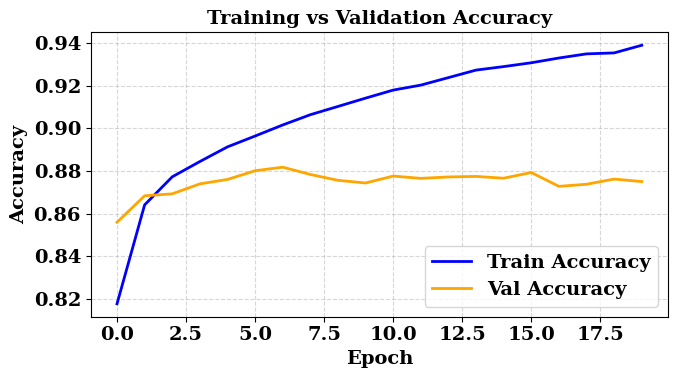

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('accuracy_curve.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()


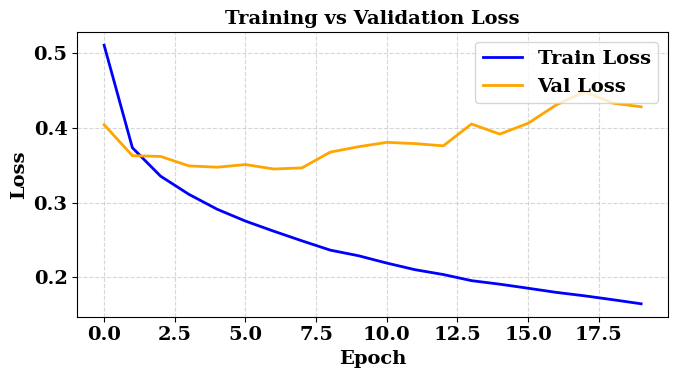

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('loss_curve.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

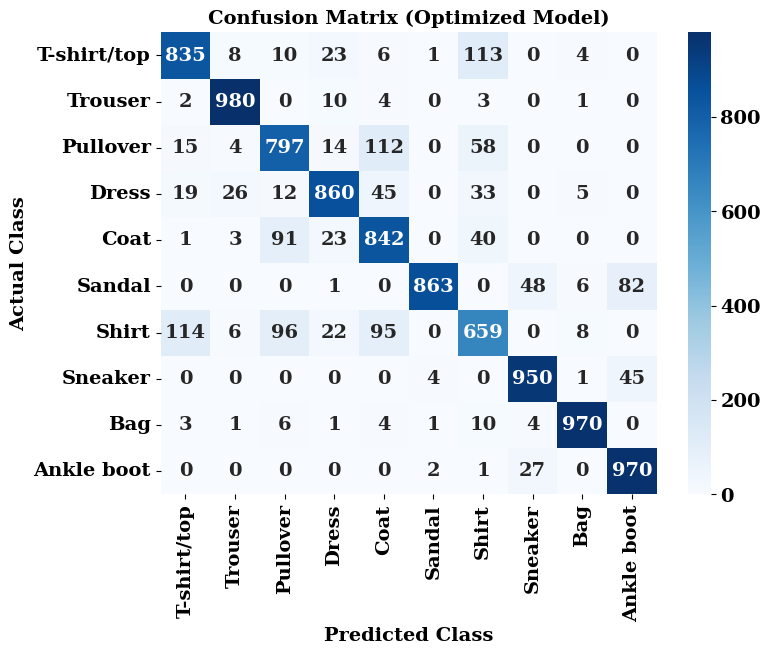

In [ ]:
# Confusion Matrix (Optimized Model)
y_true_labels = np.argmax(y_true, axis=1) if y_true.ndim > 1 else y_true
y_pred_labels = np.argmax(y_pred_opt, axis=1) if y_pred_opt.ndim > 1 else y_pred_opt

# 2. Compute Confusion Matrix using 1D arrays
cm = confusion_matrix(y_true_labels, y_pred_labels)

# 3. Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix (Optimized Model)')
plt.savefig("confusion_matrix.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()

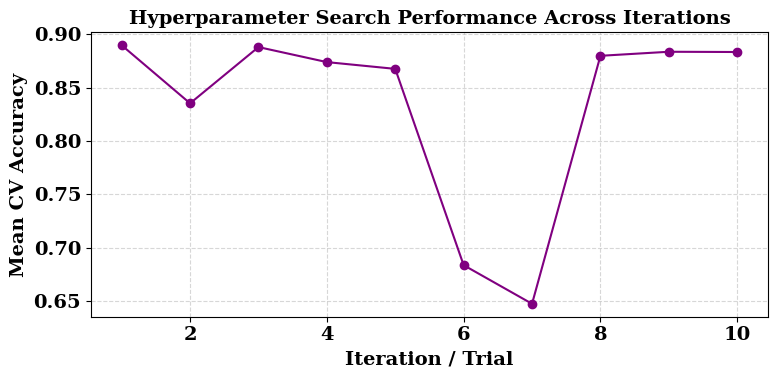

In [ ]:
# Hyperparameter Search Results across trials
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(search.cv_results_['mean_test_score']) + 1),
         search.cv_results_['mean_test_score'], marker='o', color='purple')
plt.xlabel('Iteration / Trial')
plt.ylabel('Mean CV Accuracy')
plt.title('Hyperparameter Search Performance Across Iterations')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('hyperparameter_results.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

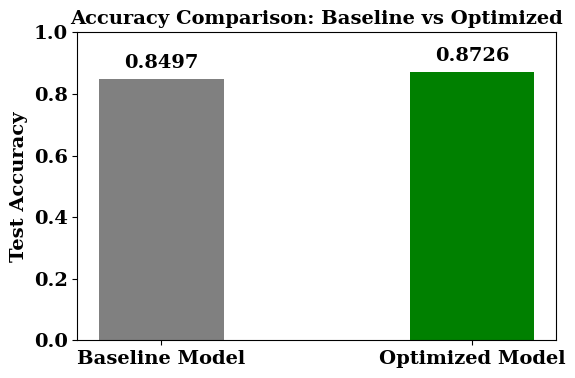

In [ ]:
models = ['Baseline Model', 'Optimized Model']
accuracies = [acc_base, acc_opt]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, accuracies, color=['gray', 'green'], width=0.4)
plt.ylim([0, 1.0])
plt.ylabel('Test Accuracy')
plt.title('Accuracy Comparison: Baseline vs Optimized')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.4f}", ha='center', va='bottom')
plt.tight_layout()
plt.savefig("accuracy_comparison.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()